# Ein mehrschichtiges Perzeptron

Das einfachte Perzeptron besitzt zwei Eingabe-Nodes und einen Ausgabe-Node, die alle entweder aktiv sind oder nicht. Damit lassen sich einfache logische Schaltungen erstellen, und das Perzeptron ist in der Lage, die richtigen Gewichte selbständig zu bestimmen - wenn die Aufgabe überhaupt lösbar ist.

Es spricht nun nichts dagegen, dass das Perzeptron mehr als nur zwei Eingabe-Kanäle besitzt und verarbeitet, und natürliche Neuronen besitzen in der Regel mehr als nur zwei Dendriten. Wir können unser Perzeptron aber auch um Ausgabe-Kanäle erweitern, wobei wir uns endgültig vom Vorbild der Natur lösen, denn ein Neuron verfügt nur über einen Ausgang: das _Axon_.

Wir wollen nun ein Perzeptron mit $J$ Eingangs-Kanälen $x_1, x_2, \ldots, x_J$ und $K$ Ausgangskanälen $o_1, o_2, \ldots, o_K$  untersuchen. Dieses Neuron verbindet  nun jeden Eingangs-Kanal $x_j$ mit jedem Ausgangs-Kanal $o_k$, wobei zu jeder Verbindung ein _Gewicht_ $w_{jk}$ und ein _Bias_ $b_j$ gehört. Die Ein- und Ausgabewerte müssen nun auch nicht mehr binär seinn.

In diesem neuen Perzeptron lautet die Aktivierungsregel bzw. 


__Perzeptron-Regel (mit Bias)__: Der Wert des Output-Neurons $o_j$ ergibt sich als gewichtete Summe der $N$ Input-Neuronen:

$$
o_j(x) = \sum_{k=1}^N w_{jk} x_k + b_j
$$

Der __Lernalgorithmus__ bleibt erhalten:

$$
\begin{equation}
\begin{split}
w_{jk} &\rightarrow w_{jk} + \alpha (t_j - o_j) x_{k}\\
b_j &\rightarrow b_j + \alpha (t_j -o_j )
\end{split}
\end{equation}
$$


### Eingabe-Vektoren und Gewichts-Matrizen

Was bedeutet der Ausdruck $w_{jk} + \alpha (t_j - o_j) x_{k}$? Die Gewichte $w_{jk}$ bilden zusammen die  __Gewichtsmatrix__, die die Gewichte aller Verbindungen von den Eingabe-Nodes $x_k$  zu den Ausgabe-Nodes $o_j$ enthält. Bei $K$ Eingabe-Nodes und $J$ Ausgabe-Nodes ist dies eine $K \times J$-Matrix. Die $J$ Fehler $(t_j - o_j)$ bilden einen _Vektor_ mit $J$ Komponenten, und die $K$ Eingabe-Nodes einen _Vektor_ mit $K$ Komponenten $x_k$. 

Wir müssen also aus dem Fehlervektor und dem Eingabevektor eine Matrix derselben Gestalt wie die Gewichtsmatrix bilden, d.h. jedes Element des Fehlervektors mit jedem Element des Eingabevektors _kombinieren_. Wir haben bereits das __Skalarprodukt__ kennengelernt, mit dem aus zwei Vektoren ein Skalar gebildet wird. Hier wollen wir nun aus zwei Vektoren eine Matrix erzeugen, und die dazugehörende mathematische Operation wird das __äußere Produkt__ oder __Tensorprodukt__ genannt (das Skalarprodukt wird dagegen auch als __inneres Produkt__ bezeichnet). Sind $W$ die Gewichtsmatrix und $(t-o)$ und $x$ die Fehler- bzw. Eingabevektoren, so schreibt sich die Lernregel kurz:

$$ W \rightarrow W + \alpha (t-o) \otimes x$$

### NumPy

Man könnte nun mit zwei for-Schleifen über $j$ und $k$ die Komponenten einzeln bestimmen und wie beim einfachen Perzeptron alles mit Basis-Methoden von Python implementieren. Wir verwenden nun aber __NumPy__, die Standard-Bibliothek der Python-Welt für mathematische Berechnungen. NumPy unterstützt alle Operationen auf Vektoren direkt, ohne dass auf einzelne Indizes zugegriffen werden muss. Damit können wir  unser Perzeptron wie folgt implementieren:

In [1]:
import numpy as np

In [ ]:
class MultiLayerPerceptron:
    """ Ein mehrschichtiges Perzeptron """
    
    def __init__(self,*nodes: list[int]) -> None:
        """ Initialisert das Perzeptron. Gewichte und Bias werden auf zufällige Werte zwischen 0 und 1 gesetzt. """
        input, output = nodes
        self.w = np.random.rand(input * output).reshape(output,input)
        self.b = np.random.rand(output)    

    def predict(self,x: list[int]) -> int:
        """ Wertet die Eingabe X mit den Gewichten aus und gibt den berechneten Wert zurück. """
        #print(x)
        return np.dot(self.w,x) + self.b

    def fit(self, X: list[int], y: list[int], alpha: float = 0.1,epochs: int = 10) ->  None:
        """ 
        Passt die Gewichte und Biases des Perzeptrons an mit Hilfe der übergebenen Daten X und Zielwerten y 
        gemäß dem Lernalgorithmus. alpha bestimmt die Lernrate und epochs die Anzahl der Durchläufe. 
        """
        for _ in range(epochs):
            for x, t in zip(X, y):  
                error = (1 * t - 1 * self.predict(x))  
                self.w += alpha * np.outer(error,x)
                self.b += alpha * error
   
    def test(self,X: list[int], y: list[int]) -> list[bool]:
        """ 
        Testet die Funktion des Perzeptrons, indem alle durch die Eingabewerte X erzeugten Ausgaben mit den 
        Zielwerten y verglichen werden.
        """
        return (y == self.predict(X))
           
    def __str__(self) -> str:
        return "Gewichte: {}, Bias = {}".format(self.w, self.b)


def normalize(X):
    """ Skaliert die Werte in einem Array X auf den Zahlenbereich [0,1] """
    return np.interp(X, (X.min(), X.max()), (0, +1))

## Anwendung des Perzeptrons

Wir probieren unser generisches Perzeptron wieder an den logischen Schaltungen aus.

In [9]:
from logic import boolean

def wahrheitstabelle(lf,name = ""):
    print(f'   a     b   |  {name}' )
    print(f'-------------|---------')
    for a, b in [ (a,b) for a in boolean for b in boolean]:
        print(f' {a!s:5} {b!s:5} | {lf((a,b))!s}')

logic_functions = {"AND": lambda a,b : a and b, 
                   "OR": lambda a,b : a or b, 
                   "NAND": lambda a,b : not (a and b), 
                   "XOR": lambda a,b : a ^ b}

inputs = [(x,y) for x in boolean for y in boolean]

for n,lf in logic_functions.items():
    t = [lf(a,b) for a,b in inputs]  
    mlp = MultiLayerPerceptron(2,1)
    mlp.fit(inputs,t)
    wahrheitstabelle(mlp.predict,n)

   a     b   |  AND
-------------|---------
 True  True  | [0.63659418]
 True  False | [0.32690845]
 False True  | [0.16965717]
 False False | [-0.14002856]
   a     b   |  OR
-------------|---------
 True  True  | [1.17040457]
 True  False | [0.64562308]
 False True  | [0.89209813]
 False False | [0.36731664]
   a     b   |  NAND
-------------|---------
 True  True  | [0.65015995]
 True  False | [0.64812133]
 False True  | [0.80446125]
 False False | [0.80242263]
   a     b   |  XOR
-------------|---------
 True  True  | [0.76000725]
 True  False | [0.48084303]
 False True  | [0.53408102]
 False False | [0.25491681]


Das Ergebnis ist wieder dasselbe, incl. XOR-Problem.

### 2. Mustererkennung

Das Perzeptron wurde auch zur Zeichenerkennung eingesetzt. Wir wollen einmal versuchen, ob wir vier verschiedenen Zeichen Ziffern zuordnen können. Unserer Zeichensatz ist also recht klein, und er besteht auch nur aus 4x4 Pixeln:

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

def plot_zeichen(z):
    img = np.reshape(z,(4,4)).astype(float)           
    plt.imshow(img,cmap='Blues')
    
def gallery(images, rows, cols, cmap=None):
    for n in range(rows * cols):          
        plt.subplot(rows, cols,n+1)
        ax = plt.gca()
        ax.axes.xaxis.set_visible(False)
        ax.axes.yaxis.set_visible(False)          
        plt.imshow(images[n], cmap) 

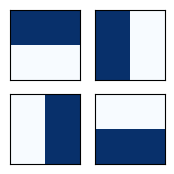

In [5]:
zeichensatz = {"eins" : np.array([1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0]),
               "zwei" : np.array([1,1,0,0,1,1,0,0,1,1,0,0,1,1,0,0]),
               "drei" : np.array([0,0,1,1,0,0,1,1,0,0,1,1,0,0,1,1]),
               "vier" : np.array([0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1])}

zeichen = list(zeichensatz.values())
werte = [1,2,3,4]

images = [np.reshape(z,(4,4)).astype(float) for z in zeichensatz.values()]

plt.figure(figsize=(2,2))
gallery(images, 2, 2, cmap='Blues');

In [6]:
mlp = MultiLayerPerceptron(16,1)
mlp.fit(zeichen,werte,epochs=1000)

In [7]:
for z,w in zip(zeichen, werte):
    print(f'{w}: {z} -> {mlp.predict(z)}')   

1: [1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0] -> [1.]
2: [1 1 0 0 1 1 0 0 1 1 0 0 1 1 0 0] -> [2.]
3: [0 0 1 1 0 0 1 1 0 0 1 1 0 0 1 1] -> [3.]
4: [0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1] -> [4.]


In [8]:
def rauschen(z,factor=0):
    return [ (1 - z if np.random.randint(100) < factor else z) for z in z]
    
for n,(z,w) in enumerate(list(zip(zeichen, werte))):
    z = rauschen(zeichen[n],10)
    print(f'{w}: {z} -> {mlp.predict(z)}')   

1: [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0] -> [1.]
2: [0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0] -> [1.65074246]
3: [0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1] -> [3.]
4: [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1] -> [3.59392046]


[1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] -> [0.22539024]


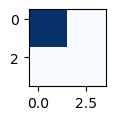

In [9]:
z = [1,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0]
plt.figure(figsize=(1,1))
plot_zeichen(z)
print(f'{z} -> {mlp.predict(z)}')

## Zeichensatz aus Sklearn

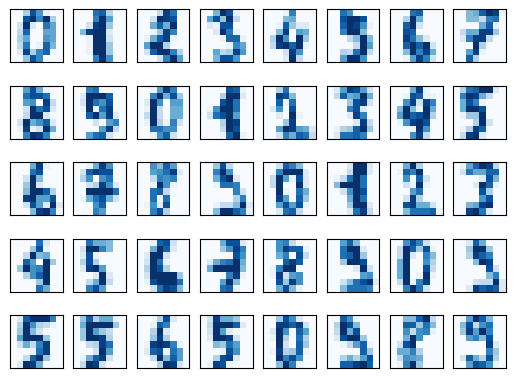

In [10]:
from sklearn.datasets import load_digits

digits = load_digits()
X, y, images = digits.data, digits.target, digits.images
#plt.figure().tight_layout()
gallery(images,5,8,cmap='Blues') ; 


In [10]:
mlp = MultiLayerPerceptron(64,10)
X = normalize(X)
mlp.fit(X, y,epochs=10)
mlp.test(X, y)

ValueError: shapes (10,64) and (1797,64) not aligned: 64 (dim 1) != 1797 (dim 0)